# **Battle of Libs**

📘 **Notebook Description**

This notebook presents a comparative analysis of three powerful data processing libraries: **Pandas, Polars, and DuckDB**. Using the New York City Taxi Trip dataset, from Kaggle, I evaluate and benchmark each tool across various dimensions such as:

* Data loading speed

* Memory usage

* Syntax clarity and developer experience

The goal is to understand the strengths and trade-offs of each library in the context of real-world data exploration and transformation tasks.

## Imports, deps and settings

In [1]:
pip install kaggle -q

In [2]:
pip install memory-profiler -q

In [36]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from google.colab import files
import pandas as pd
import polars as pl
import duckdb as db
from pathlib import Path
from datetime import datetime
from memory_profiler import memory_usage
import seaborn as sns
import matplotlib.pyplot as plt

### Kaggle Settings

In [ ]:
files.upload()

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
%cd /content/

!kaggle datasets download microize/newyork-yellow-taxi-trip-data-2020-2019

### Saving Datasets

In [ ]:
!unzip newyork-yellow-taxi-trip-data-2020-2019.zip -d newyork-yellow-taxi-trip-data

In [37]:
#files list

folder = Path('/content/newyork-yellow-taxi-trip-data')
files = [f.name for f in folder.iterdir() if f.is_file()]

## Pandas

In [ ]:
dfs = []

for file in files:

  df = pd.read_csv(f'/content/newyork-yellow-taxi-trip-data/{file}')
  filtered_df = df[df['tip_amount'] > 0]
  dfs.append(filtered_df)


base_df = pd.concat(dfs, ignore_index=True)
base_df['tpep_pickup_datetime'] = pd.to_datetime(base_df['tpep_pickup_datetime'])
base_df['hour'] = base_df['tpep_pickup_datetime'].dt.hour

tip_mean_per_hour = base_df.groupby('hour')['tip_amount'].mean()

### Gorjeta média por Horário

In [39]:
print(tip_mean_per_hour)

hour
0     3.260864
1     3.031110
2     2.898788
3     3.061240
4     3.749207
5     4.130081
6     3.045034
7     2.764387
8     2.777607
9     2.831579
10    2.916284
11    2.917608
12    2.953704
13    3.035748
14    3.112558
15    3.125849
16    3.273555
17    3.103093
18    3.012419
19    2.986563
20    3.107420
21    3.155693
22    3.216239
23    3.232551
Name: tip_amount, dtype: float64


### To Parquet

In [40]:
start = datetime.now()

def save_parquet():
  (
    tip_mean_per_hour
    .to_frame()
    .to_parquet('/content/parquet_files/tip_mean_per_hour_pandas.parquet')
  )

mem_usage = memory_usage(save_parquet)

end = datetime.now()

In [41]:
time_in_sec = (end - start).total_seconds()

results_df = pd.DataFrame({
  'lib': ['pandas'],
  'max_memory_use': [max(mem_usage)],
  'min_memory_use': [min(mem_usage)],
  'total_memory_use': [max(mem_usage) - min(mem_usage)],
  'time_in_sec': [time_in_sec]
})

## Polars

In [42]:
dfs = []

for file in files:
  df = pl.read_csv(
    f'/content/newyork-yellow-taxi-trip-data/{file}',
    infer_schema_length=10000,
    schema_overrides={
      'tip_amount': pl.Float64,
      'tolls_amount': pl.Float64,
      'fare_amount': pl.Float64,
      'total_amount': pl.Float64,
    }
  )

  filtered_df = df.filter(pl.col('tip_amount') > 0)

  dfs.append(filtered_df)

In [43]:
base_df = pl.concat(dfs)

base_df = (
  base_df
  .with_columns([pl.col('tpep_pickup_datetime').str.to_datetime().alias('tpep_pickup_datetime')])
  .with_columns([pl.col('tpep_pickup_datetime').dt.hour().alias('hour')])
)

tip_mean_per_hour = (
  base_df
  .group_by('hour')
  .agg(
    pl.col('tip_amount').mean().alias('tip_amount_mean')
    )
)

### Gorjeta média por Horário

In [44]:
print(tip_mean_per_hour)

shape: (24, 2)
┌──────┬─────────────────┐
│ hour ┆ tip_amount_mean │
│ ---  ┆ ---             │
│ i8   ┆ f64             │
╞══════╪═════════════════╡
│ 15   ┆ 3.125849        │
│ 12   ┆ 2.953704        │
│ 9    ┆ 2.831579        │
│ 1    ┆ 3.03111         │
│ 18   ┆ 3.012419        │
│ …    ┆ …               │
│ 17   ┆ 3.103093        │
│ 10   ┆ 2.916284        │
│ 14   ┆ 3.112558        │
│ 5    ┆ 4.130081        │
│ 6    ┆ 3.045034        │
└──────┴─────────────────┘


### To Parquet

In [45]:
start = datetime.now()

def save_parquet():
  (
    tip_mean_per_hour
    .write_parquet("/content/parquet_files/tip_mean_per_hour_polars.parquet")
  )

mem_usage = memory_usage(save_parquet)

end = datetime.now()

In [46]:
time_in_sec = (end - start).total_seconds()

results_polars_df = pd.DataFrame({
  'lib': ['polars'],
  'max_memory_use': [max(mem_usage)],
  'min_memory_use': [min(mem_usage)],
  'total_memory_use': [max(mem_usage) - min(mem_usage)],
  'time_in_sec': [time_in_sec]
})

results_df = pd.concat([results_df, results_polars_df], ignore_index=True)

## DuckDB

In [ ]:
con = db.connect(database=':memory:')

base_path = '/content/newyork-yellow-taxi-trip-data'

for i, file in enumerate(files):
    path = f"{base_path}/{file}"

    query = f"""
        SELECT
          *,
          EXTRACT(HOUR FROM tpep_pickup_datetime::TIMESTAMP) AS hour
        FROM read_csv_auto('{path}')
        WHERE tip_amount > 0
    """

    if i == 0:
      con.execute(f"CREATE TABLE base_df AS {query}")
    else:
      con.execute(f"INSERT INTO base_df {query}")

tip_mean_per_hour = con.execute("""
    SELECT hour, AVG(tip_amount) AS tip_mean
    FROM base_df
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

### Gorjeta média por Horário

In [48]:
print(tip_mean_per_hour)

    hour  tip_mean
0      0  3.260864
1      1  3.031110
2      2  2.898788
3      3  3.061240
4      4  3.749207
5      5  4.130081
6      6  3.045034
7      7  2.764387
8      8  2.777607
9      9  2.831579
10    10  2.916284
11    11  2.917608
12    12  2.953704
13    13  3.035748
14    14  3.112558
15    15  3.125849
16    16  3.273555
17    17  3.103093
18    18  3.012419
19    19  2.986563
20    20  3.107420
21    21  3.155693
22    22  3.216239
23    23  3.232551


### To Parquet

In [49]:
start = datetime.now()

def save_parquet():
  db.sql("""
      COPY (
          SELECT *
          FROM tip_mean_per_hour
      ) TO '/content/parquet_files/tip_mean_per_hour_duckdb.parquet' (FORMAT 'parquet');
    """)

mem_usage = memory_usage(save_parquet)

end = datetime.now()

In [50]:
time_in_sec = (end - start).total_seconds()

results_duckdb_df = pd.DataFrame({
  'lib': ['duckdb'],
  'max_memory_use': [max(mem_usage)],
  'min_memory_use': [min(mem_usage)],
  'total_memory_use': [max(mem_usage) - min(mem_usage)],
  'time_in_sec': [time_in_sec]
})

results_df = pd.concat([results_df, results_duckdb_df], ignore_index=True)

## Gráficos

### Tempo de Execução por Biblioteca

/tmp/ipython-input-51-1185528706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='lib', y='time_in_sec', palette='viridis')


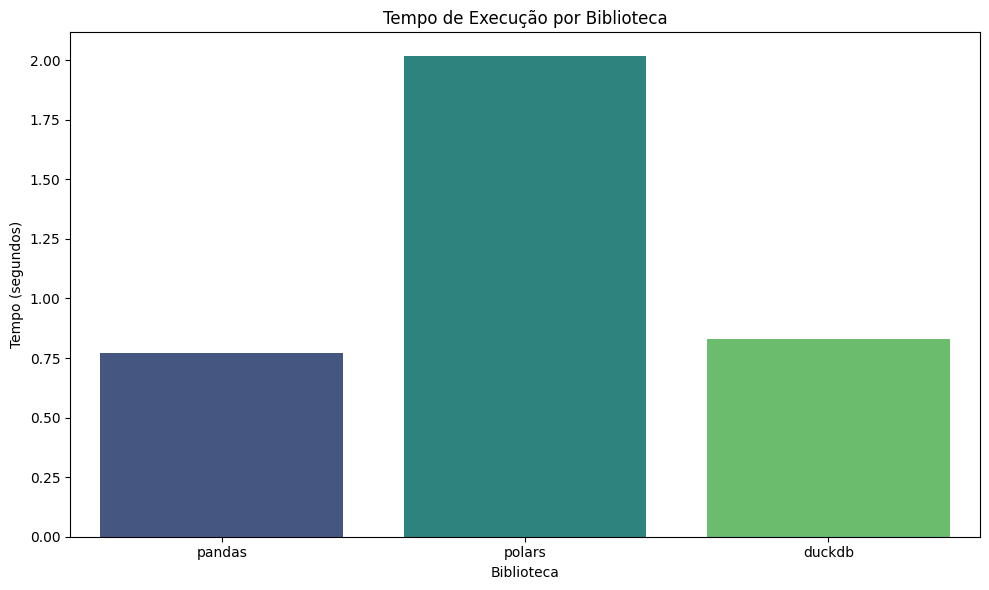

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='lib', y='time_in_sec', palette='viridis')

plt.title('Tempo de Execução por Biblioteca')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Biblioteca')
plt.tight_layout()
plt.show()

### Total de Memória por Biblioteca

/tmp/ipython-input-52-2473467341.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='lib', y='total_memory_use', palette='viridis')


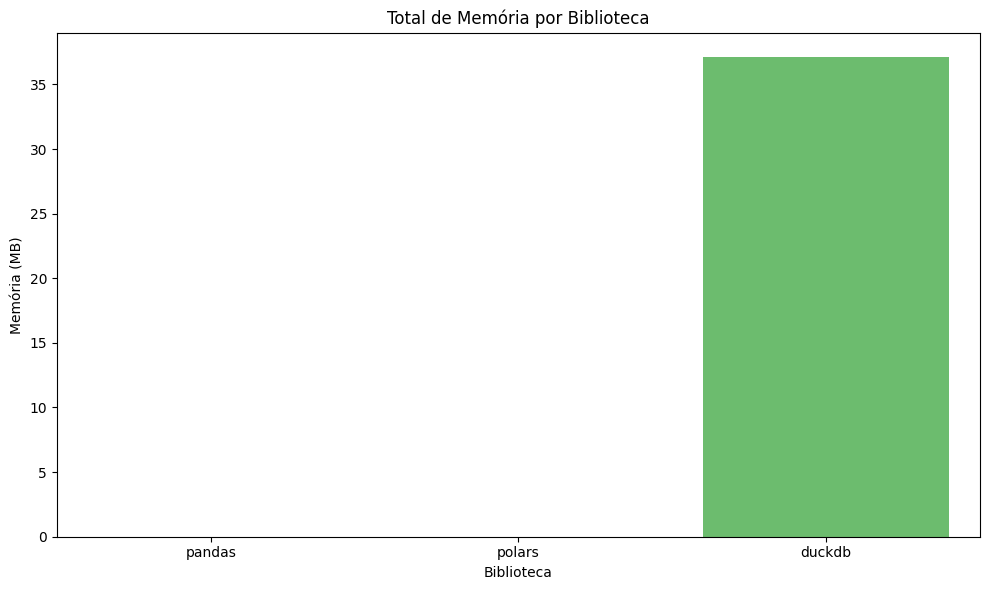

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='lib', y='total_memory_use', palette='viridis')

plt.title('Total de Memória por Biblioteca')
plt.ylabel('Memória (MB)')
plt.xlabel('Biblioteca')
plt.tight_layout()
plt.show()

### Pico máximo de Memória por *Biblioteca*

/tmp/ipython-input-53-3315363805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='lib', y='max_memory_use', palette='viridis')


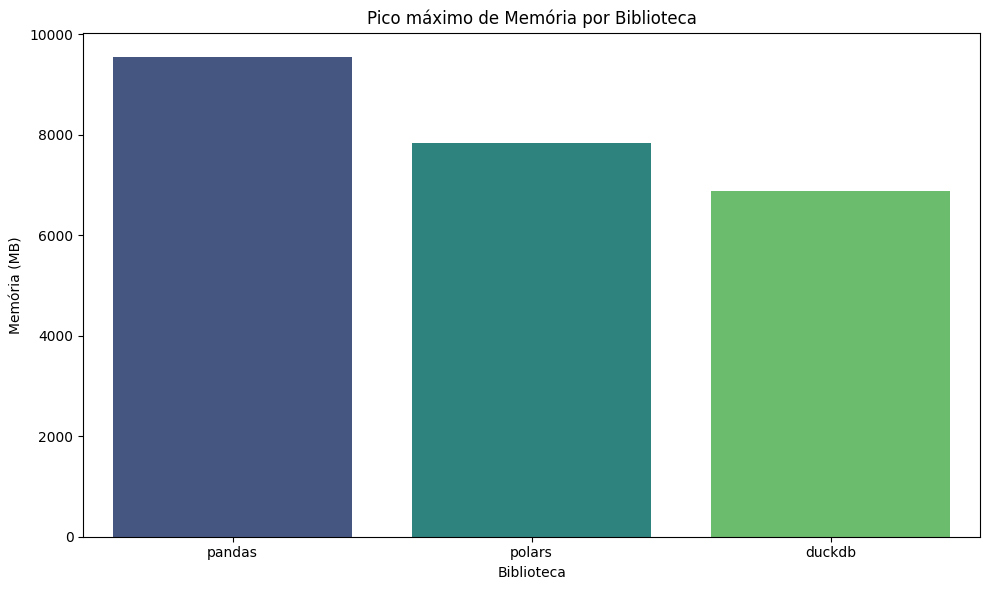

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='lib', y='max_memory_use', palette='viridis')

plt.title('Pico máximo de Memória por Biblioteca')
plt.ylabel('Memória (MB)')
plt.xlabel('Biblioteca')
plt.tight_layout()
plt.show()